## Dataset review aplikasi DJPajak
Mengunakan data emotion classify

Preprocessing step 1
- lower case
- contraction
- remove number or convert number
- remove punctuation
- remove stopwords
- combine preprocessing method

Preprocessing step 2
- stemming



# Import Library

In [393]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load Dataset

In [ ]:
df = pd.read_csv('/Users/genovevakameubun/Documents/DS/Portofolio/djpajakappreview.csv')
df.head()


,score,content,at
0,1,"apk yang lama sudah bagus, dan apk yang sekarang gak bisa di akses, buang"" anggaran negara saja",2025-04-28 23:48:03
1,1,Aplikasi Sampah,2025-04-28 20:56:17
2,1,aplikasi sampah,2025-04-28 12:57:49
3,1,"koq smakin jelek saja rating aplikasi Perpajakan ini, ada apa yaaa... knapa kntr pajak tdk review aplikasi DJP ini.",2025-04-28 09:25:05
4,1,pelayanan di kantor jelek sekali.,2025-04-28 09:09:08


In [396]:
print(df.head(20).to_string()) 

    score                                                                                                                                                                                                                                                                                                                                                                                                                    content                   at
0       1                                                                                                                                                                                                                                                                                                                            apk yang lama sudah bagus, dan apk yang sekarang gak bisa di akses, buang" anggaran negara saja  2025-04-28 23:48:03
1       1                                                                                                           

In [397]:
df.shape

(3005, 3)

# EDA

In [398]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3005 entries, 0 to 3004
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   score    3005 non-null   int64 
 1   content  3005 non-null   object
 2   at       3005 non-null   object
dtypes: int64(1), object(2)
memory usage: 70.6+ KB


In [434]:
df.describe()

,score
count,3005.000000
mean,1.707820
std,1.443967
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,5.000000


In [399]:
df.isna().sum()

score      0
content    0
at         0
dtype: int64

#### Distribusi Skor

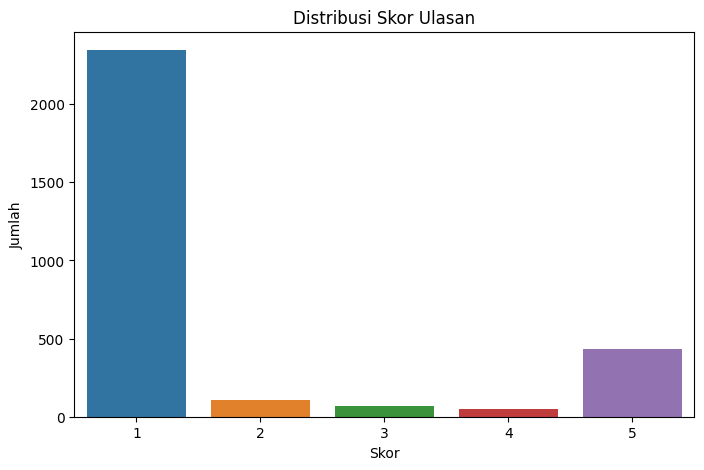

In [400]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.countplot(x='score', data=df)
plt.title('Distribusi Skor Ulasan')
plt.xlabel('Skor')
plt.ylabel('Jumlah')
plt.show()

#### Tren skor rata-rata per bulan

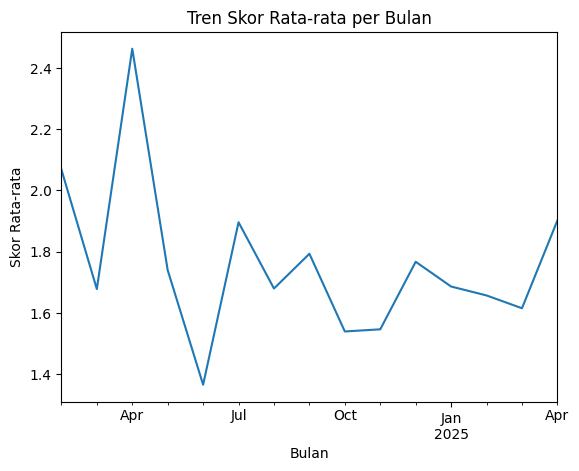

In [401]:
df['at'] = pd.to_datetime(df['at'])  
df.groupby(df['at'].dt.to_period('M'))['score'].mean().plot()
plt.title('Tren Skor Rata-rata per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Skor Rata-rata')
plt.show()

#### Boxplot-Outlier

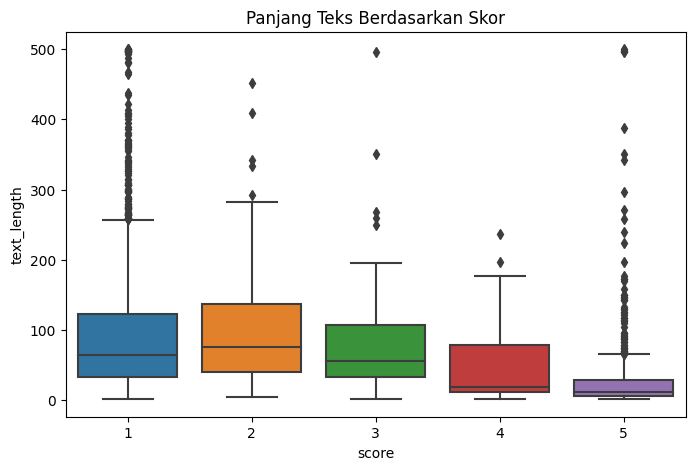

In [403]:
df['text_length'] = df['content'].apply(len)
plt.figure(figsize=(8, 5))
sns.boxplot(x='score', y='text_length', data=df)
plt.title('Panjang Teks Berdasarkan Skor')
plt.show()

In [ ]:
# pip install tabulate



[notice] A new release of pip is available: 23.2.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from tabulate import tabulate

print("\nRingkasan Upper Bound dan Outlier:")
summary = []
for skor in sorted(df['score'].unique()):
    subset = df[df['score'] == skor]
    upper = hitung_upper_bound(subset['text_length'])
    outliers = subset[subset['text_length'] > upper]
    summary.append([skor, upper, outliers.shape[0]])
    outlier_komentar = pd.concat([outlier_komentar, outliers])

print(tabulate(summary, headers=["Score", "Upper Bound", "Jumlah Outlier"], tablefmt="grid"))



print("\nContoh Komentar Outlier:")
print(tabulate(
    outlier_komentar[['score', 'text_length', 'content']].head(),
    headers='keys',
    tablefmt='grid',
    showindex=False
))



Ringkasan Upper Bound dan Outlier:
+---------+---------------+------------------+
|   Score |   Upper Bound |   Jumlah Outlier |
+=========+===============+==================+
|       1 |       260.5   |               25 |
+---------+---------------+------------------+
|       2 |       286.75  |                2 |
+---------+---------------+------------------+
|       3 |       195.25  |                3 |
+---------+---------------+------------------+
|       4 |       200.5   |                1 |
+---------+---------------+------------------+
|       5 |        87.875 |               17 |
+---------+---------------+------------------+

Contoh Komentar Outlier:
+---------+---------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

#### Duplikat

In [405]:
print(f"Jumlah duplikasi: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape setelah hapus duplikasi: {df.shape}")

Jumlah duplikasi: 0
Shape setelah hapus duplikasi: (3005, 4)


# Preprocessing Step 1

### Lowercase, Remove Number, Extra space, punctualitation, contraction, Stopwords

In [ ]:
import pandas as pd
import re
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

#Download resource nltk
nltk.download('punkt')
nltk.download('stopwords')


In [ ]:
#Stopwords Indonesia + tambahan kata tidak penting
stop_words = set(stopwords.words('indonesian'))
stop_words.update([
    'nya', 'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 
    'seperti', 'dll', 'ini', 'itu', 'itu', 'pada', 'tersebut', 'agar', 
    'akan', 'adalah', 'oleh', 'juga', 'karena', 'sehingga', 'atau', 'aplikasi',
    'saya', 'kamu', 'mereka', 'kami', 'kita', 'itu', 'ini', 'apa', 'iya', 'apk',
    'aplikasi', 'aplikasii', 'aplikasiii', 'aplikasiiii', 'aplikasiiiii', 'pajak', 'trsss'
])

important_words = ['cukup', 'bagus', 'baik', 'jelek', 'buruk', 'mantap', 'top']
stop_words -= set(important_words)

kamus_singkat = {
    'gmn': 'gimana',
    'udh': 'sudah',
    'tdk': 'tidak',
    'ga': 'tidak',
    'gak': 'tidak',
    'gk': 'tidak',
    'dr': 'dari',
    'yg': 'yang',
    'tp': 'tapi',
    'kl': 'kalau',
    'klo': 'kalau',
    'dgn': 'dengan',
    'aja': 'saja',
    'blm': 'belum',
    'ok': 'oke',
    'bgt': 'banget',
    'ilang': 'hilang',
    'korup': 'korupsi',
    'lemot': 'lambat',
    'nggak': 'tidak', 
    'ya': 'iya',
    'sdh': 'sudah',
    'bgt': 'banget',
    'efrin': 'efin',
    'mantab': 'mantap',
    'mantap': 'mantap',
    'muannntapppp': 'mantap',
    'mantep': 'mantap',
    'buruuuukkkkk': 'buruk',
    'burukkkk': 'buruk',
    'matap': 'mantap',
    'ribet': 'sulit',
    'susah': 'sulit',
    'jos': 'bagus',
    'mantul': 'mantap'

}

#Fungsi untuk normalisasi kata
def normalisasi_kata(kata):
    return kamus_singkat.get(kata, kata)

#Fungsi untuk menghapus huruf berulang lebih dari 2 kali di akhir kata
def clean_text(text):
    # ... (kode sebelumnya)
    words = [kamus_singkat.get(remove_repeated_characters(w), w) for w in words]
    # ... (lanjutan kode)

#Fungsi Cleaning teks
def clean_text(text):
    if pd.isnull(text):
        return ""
    
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\S+", "", text)  
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)       
    text = re.sub(r'\s+', ' ', text).strip()         
    
    words = word_tokenize(text)                      
    words = [normalisasi_kata(w) for w in words]
    words = [remove_repeated_characters(w) for w in words]
    words = [re.sub(r"[^\w\s]", "", w) for w in words]  
    words = [re.sub(r"\d+", "", w) for w in words]      
    words = [w for w in words if w not in stop_words and w.strip() != ""]
    
    return " ".join(words)


df['clean_content'] = df['content'].apply(clean_text)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/genovevakameubun/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/genovevakameubun/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Preprossesing Step 2

In [407]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text):
    return stemmer.stem(text)

df['stemmed_content'] = df['clean_content'].apply(stemming)

In [408]:
from tqdm import tqdm
tqdm.pandas()  #Untuk progress bar
df['stemmed_content'] = df['clean_content'].progress_apply(stemming)


100%|██████████| 3005/3005 [00:00<00:00, 34826.98it/s]


In [409]:
pd.options.display.max_colwidth = None


#### Dataset Awal- Dataset Setelah Preprocessing 1 - Dataset Setelah Preprocessing 2

In [411]:
df.head(20)

,score,content,at,text_length,clean_content,stemmed_content
0,1,"apk yang lama sudah bagus, dan apk yang sekarang gak bisa di akses, buang"" anggaran negara saja",2025-04-28 23:48:03,95,bagus akses buang anggaran negara,bagus akses buang anggar negara
1,1,Aplikasi Sampah,2025-04-28 20:56:17,15,sampah,sampah
2,1,aplikasi sampah,2025-04-28 12:57:49,15,sampah,sampah
3,1,"koq smakin jelek saja rating aplikasi Perpajakan ini, ada apa yaaa... knapa kntr pajak tdk review aplikasi DJP ini.",2025-04-28 09:25:05,115,koq smakin jelek rating perpajakan yaa knapa kntr review djp,koq smakin jelek rating paja yaa knapa kntr review djp
4,1,pelayanan di kantor jelek sekali.,2025-04-28 09:09:08,33,pelayanan kantor jelek,layan kantor jelek
5,1,coretaxnya cacat,2025-04-28 09:01:41,16,coretaxnya cacat,coretaxnya cacat
6,1,error ga bisa login,2025-04-27 19:39:27,19,error login,error login
7,5,cukup bagus,2025-04-26 13:33:46,11,cukup bagus,cukup bagus
8,1,aplikasi indo emang gini,2025-04-26 11:22:01,24,indo emang gini,indo emang gin
9,1,jelek bgt sumpah,2025-04-25 21:30:30,16,jelek banget sumpah,jelek banget sumpah


#### untuk melihat perbedaan lebih jelas

In [414]:
df.loc[[13,16, 17, 18,19], ["content",'clean_content','stemmed_content']]

,content,clean_content,stemmed_content
13,sangat membantu,membantu,bantu
16,"aplikasi sampahh lemotttnya luarr biasa aplikasi masih cacat, mana pelayanan di KANTOR PAJAKnya juga sama lagi kayak aplikasinya sama² lemot nunggu berjam² Unjung²nya tidak dilayani malah disuruh pulang besok kesini lagi(KANTOR PAJAK),. tolong segera direformasi sistem perpajakan di Indonesia KAMI HANYA INGIN BAYAR PAJAK BUKAN MENCURI UANG NEGARA, dimana ujung² nya uang PAJAK KAMI DIKORUPSI PARA PEJABATNYA",sampahh lemottnya luarr cacat pelayanan kantor pajaknya kayak aplikasinya lambat nunggu berjam unjung dilayani disuruh pulang besok kesini kantor tolong direformasi sistem perpajakan indonesia bayar mencuri uang negara dimana ujung uang dikorupsi pejabatnya,sampahh lemottnya luarr cacat layan kantor pajak kayak aplikasi lambat nunggu jam unjung layan suruh pulang besok kesini kantor tolong reformasi sistem paja indonesia bayar curi uang negara mana ujung uang korupsi jabat
17,"sering logout , minta verifikasi ke email gak muncul muncul . tolong dong diperbaiki permasalahannya",logout verifikasi email muncul muncul tolong diperbaiki permasalahannya,logout verifikasi email muncul muncul tolong baik masalah
18,"mau ngurus lupa EFIN dari aplikasi bisa tapi harus ngantri 600 pengatri dulu, di tunggu sampe sore eh malah tiba "" system eror, lalu coba lagi di hari berikutnya malah kesalahan server, masa pelayanan dikantor ama aplikasinya sama "" buruk 👎👎hadeh..",ngurus lupa efin ngantri pengatri tunggu sampe sore eh system eror coba kesalahan server pelayanan dikantor ama aplikasinya buruk hadeh,ngurus lupa efin ngantri pengatri tunggu sampe sore eh system eror coba salah server layan kantor ama aplikasi buruk hadeh
19,aplikasi terjelek👎,terjelek,jelek


### Tambahan Fitur

In [415]:

def kategori_rating(score):
    if score in [1, 2]:
        return 'rendah'
    elif score == 3:
        return 'sedang'
    else:  # score in [4, 5]
        return 'tinggi'

df['kategori'] = df['score'].apply(kategori_rating)

fitur_dict = {
    'cepat': ['cepat', 'responsif', 'lancar'],
    'tampil': ['tampil', 'ui', 'antarmuka', 'desain'],
    'login': ['login', 'masuk', 'log in'],
    'fitur': ['fitur', 'fungsi', 'menu'],
    'bug': ['bug', 'glitch', 'cacat'],
    'error': ['error', 'eror', 'gagal'],
    'loading': ['loading', 'lambat', 'muat'],
    'efin': ['efin', 'efin', 'electronic filing'],
    'update': ['update', 'perbarui', 'upgrade']
}
fitur_kepuasan = []
for fitur, sinonim in fitur_dict.items():
    for kategori in ['rendah', 'sedang', 'tinggi']:
        count = df[df['clean_content'].str.contains('|'.join(sinonim), case=False, na=False) & (df['kategori'] == kategori)].shape[0]
        fitur_kepuasan.append({'fitur': fitur, 'kategori': kategori, 'jumlah': count})
df_fitur_kepuasan = pd.DataFrame(fitur_kepuasan)


In [416]:
df

,score,content,at,text_length,clean_content,stemmed_content,kategori
0,1,"apk yang lama sudah bagus, dan apk yang sekarang gak bisa di akses, buang"" anggaran negara saja",2025-04-28 23:48:03,95,bagus akses buang anggaran negara,bagus akses buang anggar negara,rendah
1,1,Aplikasi Sampah,2025-04-28 20:56:17,15,sampah,sampah,rendah
2,1,aplikasi sampah,2025-04-28 12:57:49,15,sampah,sampah,rendah
3,1,"koq smakin jelek saja rating aplikasi Perpajakan ini, ada apa yaaa... knapa kntr pajak tdk review aplikasi DJP ini.",2025-04-28 09:25:05,115,koq smakin jelek rating perpajakan yaa knapa kntr review djp,koq smakin jelek rating paja yaa knapa kntr review djp,rendah
4,1,pelayanan di kantor jelek sekali.,2025-04-28 09:09:08,33,pelayanan kantor jelek,layan kantor jelek,rendah
...,...,...,...,...,...,...,...
3000,1,Ud di isi dan foto ternyata gagal..,2024-02-01 15:33:14,35,ud isi foto gagal,ud isi foto gagal,rendah
3001,1,Mohon lebih di tingkatkan unt pelayan,2024-02-01 13:47:17,37,mohon tingkatkan unt pelayan,mohon tingkat unt layan,rendah
3002,1,Nomor NIK 16 digit tapi limit pengisian NIK utk login hanya 15 digit. Lalu bagaimana saya mendaftar,2024-02-01 09:30:02,99,nomor nik digit limit pengisian nik utk login digit mendaftar,nomor nik digit limit isi nik utk login digit daftar,rendah
3003,1,Lama kode verifikasi pas saat login sampai sekarang saya tidak bisa login karena kode verifikasi,2024-02-01 09:28:09,96,kode verifikasi pas login login kode verifikasi,kode verifikasi pas login login kode verifikasi,rendah


# Visualisasi

### WordFrequensi


In [417]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [418]:
from collections import Counter
all_words = " ".join(df['clean_content']).split()
word_freq = Counter(all_words)
print(pd.Series(word_freq).sort_values(ascending=False).head(20))


sulit          533
efin           319
kode           298
email          282
verifikasi     279
login          264
masuk          259
bikin          222
banget         205
npwp           200
udah           193
daftar         179
bayar          179
lapor          160
otp            153
pemerintah     152
lupa           144
aplikasinya    141
sampah         136
membantu       135
dtype: int64


In [419]:
#Gabungan Score 5 dan 4 jadi 'Tinggi'
kamus_tinggi = kamus(df[df['score'].isin([5, 4])]['stemmed_content'])
kamus_sedang = kamus(df[df['score'] == 3]['stemmed_content'])
kamus_rendah = kamus(df[df['score'].isin([1, 2])]['stemmed_content'])

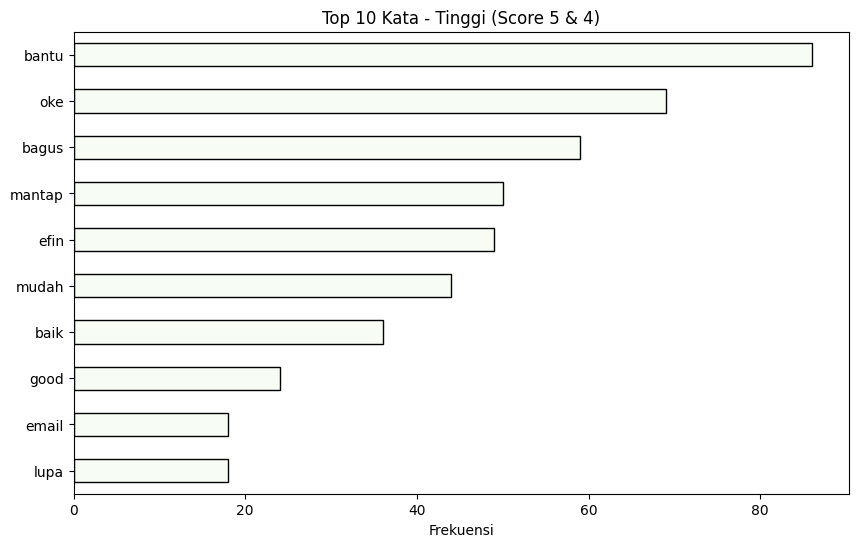

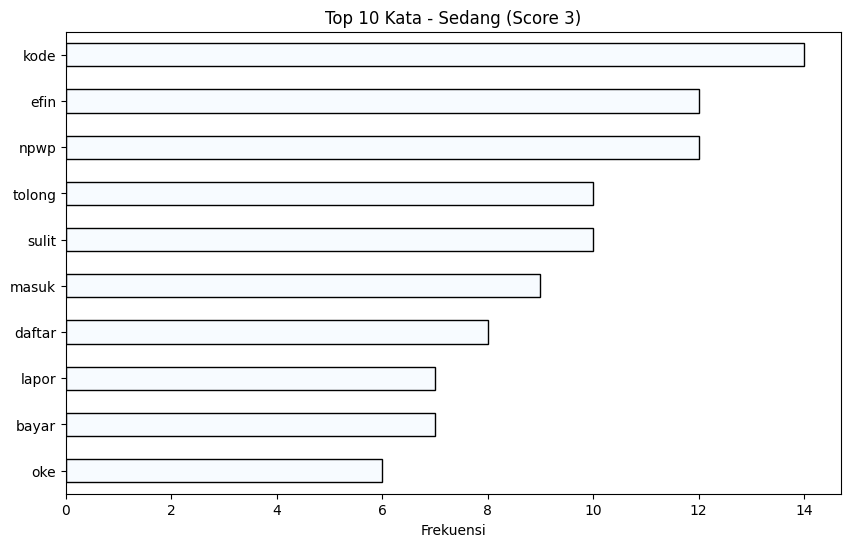

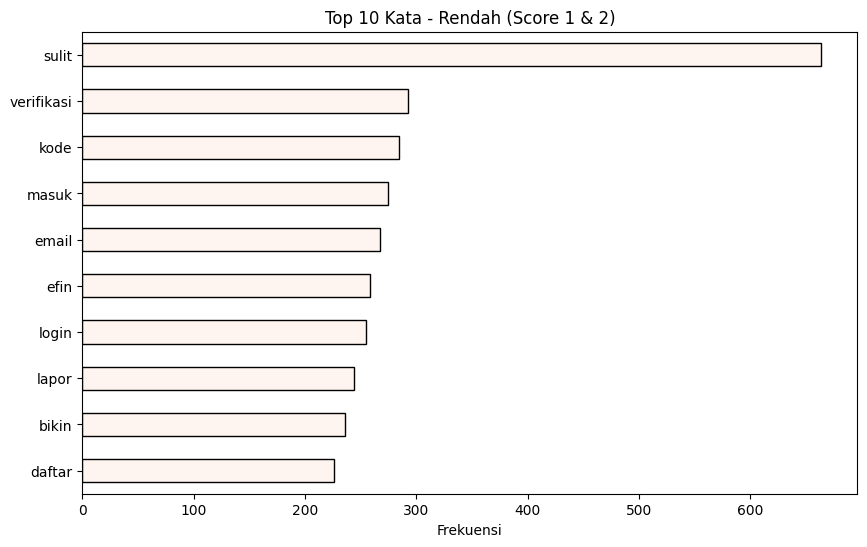

In [ ]:
#Tinggi
plt.figure(figsize=(10, 6))
kamus_tinggi[:10].plot(kind='barh', colormap='Greens', edgecolor='black')
plt.title("Top 10 Kata - Tinggi (Score 5 & 4)")
plt.xlabel("Frekuensi")
plt.gca().invert_yaxis()
plt.show()

#Sedang
plt.figure(figsize=(10, 6))
kamus_sedang[:10].plot(kind='barh', colormap='Blues', edgecolor='black')
plt.title("Top 10 Kata - Sedang (Score 3)")
plt.xlabel("Frekuensi")
plt.gca().invert_yaxis()
plt.show()

#Rendah
plt.figure(figsize=(10, 6))
kamus_rendah[:10].plot(kind='barh', colormap='Reds', edgecolor='black')
plt.title("Top 10 Kata - Rendah (Score 1 & 2)")
plt.xlabel("Frekuensi")
plt.gca().invert_yaxis()
plt.show()

### WordCloud

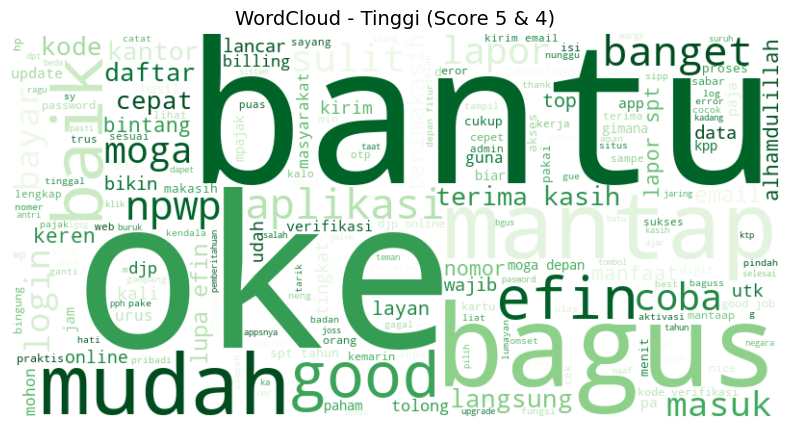

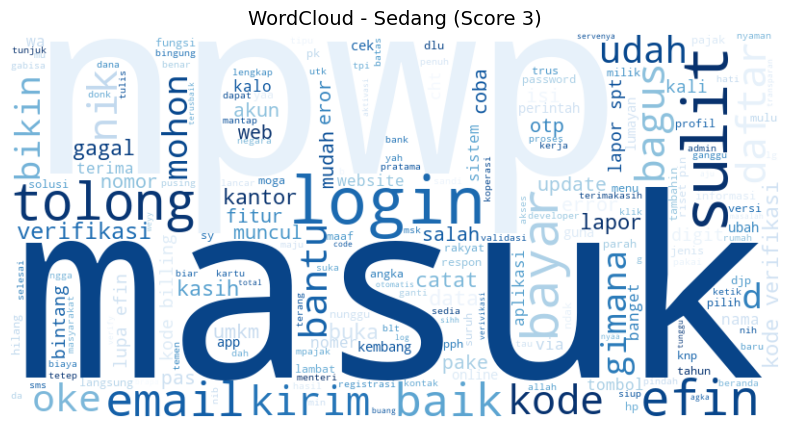

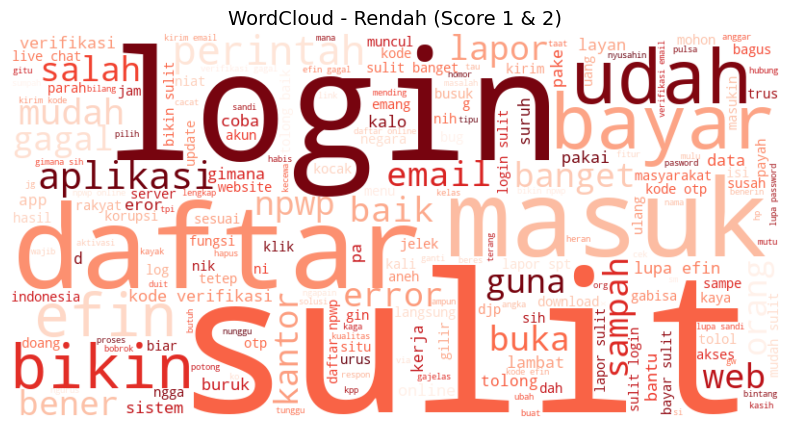

In [ ]:
#WordCloud - Tinggi (Score 5 & 4)
text_tinggi = " ".join(df[df['score'].isin([5, 4])]['stemmed_content'].dropna())
wordcloud_tinggi = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(text_tinggi)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_tinggi, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Tinggi (Score 5 & 4)", fontsize=14)
plt.show()

#WordCloud - Sedang
text_sedang = " ".join(df[df['score'] == 3]['stemmed_content'].dropna())
wordcloud_sedang = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(text_sedang)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_sedang, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Sedang (Score 3)", fontsize=14)
plt.show()

#WordCloud - Rendah
text_rendah = " ".join(df[df['score'].isin([1, 2])]['stemmed_content'].dropna())
wordcloud_rendah = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_rendah)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_rendah, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Rendah (Score 1 & 2)", fontsize=14)
plt.show()

### BarStack- Tingkat Kepuasan

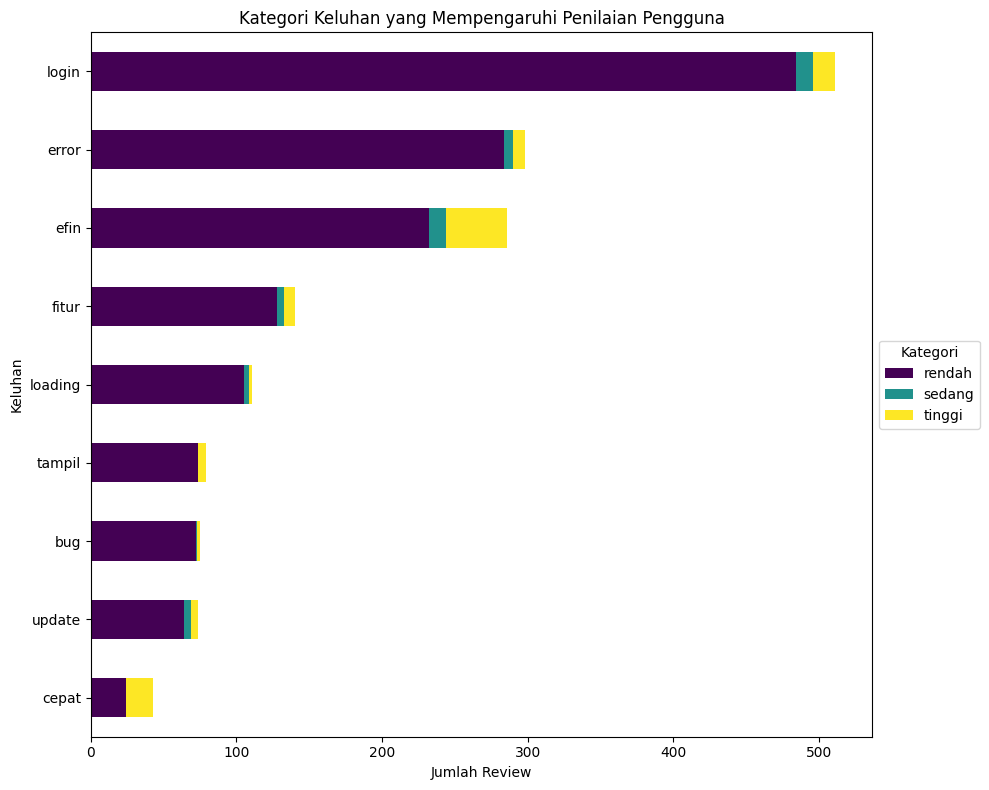

In [ ]:
pivot_df.plot(kind='barh', stacked=True, figsize=(10, 8), colormap='viridis')

plt.title("Kategori Keluhan yang Mempengaruhi Penilaian Pengguna")
plt.xlabel("Jumlah Review")
plt.ylabel("Keluhan")

plt.legend(title='Kategori', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()
